In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_parquet(r"C:\Users\91891\Downloads\customer-churn-intelligence-system\data\optimized_df.parquet")
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


### So before splitting data
* remove duplicates
* invalid values
* basic cleaning
##### If we are trying to impute missing values, or do encoding or any sort of technique which involves the full data values, then that is data leakage, so fit on train and trasform on train and test.

In [3]:
print(df.duplicated().sum())
# no duplicate rows
print(df.columns.duplicated().sum())
# any duplicate column, which checks same column names
duplicate_cols = []
for i in range(len(df.columns)):
    for j in range(i+1,len(df.columns)):
        if df.iloc[:,i].equals(df.iloc[:,j]):
            #  here .iloc[rows,cols], all rows, and in the column position
            # equals() is a pandas method used to check whether, 2 pandas objects are exactly equal or not.
            # It compares both series and dataframes.
            # It returns True if all values are euqal else false.
            duplicate_cols.append(df.columns[i],df.columns[j])
print(duplicate_cols)
# which checks the values, if the column names are different, but values are same,

0
0
[]


### Problems to be addressed
1. Certain records violate expected business relationships where Average_Order_Value exceeds Lifetime_Value
but the percentage is very low, which is 0.29% ~ 0.3%.
Given the very low occurrence rate, these records were retained while documenting the limitation as a potential synthetic data artifact.

2. Age col as min is 5 annd max is 200, both are to be addressed.
3. Cart_Abandonment_Rate is the percentage it exceeding 100, as max value is 143.

4. Total_purchases min value is -13.

5. discount_rate also exceeded 100.


### AGE

In [4]:
len(df[df["Age"] < 18])

26

In [5]:
len(df[df["Age"] > 90])

16

### Age validation
* The Age column contained unrealistic values below 18 and above 90.
* Since the dataset represents ecommerce customer behavior, ages outside the 18–90 range were considered invalid for the business context.
* A total of 42 invalid records (~0.08% of the dataset) were removed during preprocessing.

In [6]:
# df = df[(df["Age"] < 18) | (df["Age"] > 90)]
# if im doing the above operation, it is also removing the rows where age is NaN, so include that also
# df = df[(df["Age"].isna()) | ((df["Age"] >= 18) & (df["Age"] <= 90))]

In [7]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


In [8]:
# After validating the remaining feature values in affected records, invalid values were replaced with NaN and will be handled later during missing value imputation.

In [9]:
df.loc[(df["Age"] < 18) | (df["Age"] > 90),"Age"] = np.nan

In [10]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


### Percentage exceeding 100
* Features to validate
* Cart Abandonment Rate
* Discount Usage Rate
* So these should not exceed 100 and not be less than 0, but as we saw in univariate analysis(max and min) value.
* So convert these values to NaN

In [11]:
len(df[df["Cart_Abandonment_Rate"] < 0])

0

In [12]:
len(df[df["Cart_Abandonment_Rate"] > 100])

25

In [13]:
df.loc[df["Cart_Abandonment_Rate"] > 100,"Cart_Abandonment_Rate"]= np.nan

In [14]:
len(df[df["Discount_Usage_Rate"] < 0])

0

In [15]:
len(df[df["Discount_Usage_Rate"] > 100])

165

In [16]:
df.loc[df["Discount_Usage_Rate"] > 100,"Discount_Usage_Rate"] = np.nan

In [17]:
df[df["Total_Purchases"] < 0][["Total_Purchases","Returns_Rate"]]
# as in total_purchases, sometimes, negative also can mean returns,
# for example they bought 10 items, in a time window, but data is calculated in another window where they returned
# 13 items, that means before that window puchased items, then it would be -3, but if we check
# that with return rate that is normal only, so decided to replace with NaN


# The Total_Purchases feature contained negative values, which is inconsistent with expected ecommerce purchasing behavior.
# Initially, the possibility of refund or return-based business logic was considered. However, corresponding Returns_Rate values remained within normal ranges and did not support unusually high return activity.
# Since both features would typically be expected to represent behavior within a similar observation period, the negative purchase values were treated as unrealistic or synthetic data artifacts.
# Therefore, invalid purchase values were replaced with NaN and will later be handled during missing value treatment.

,Total_Purchases,Returns_Rate
2319,-9.1,9.8
3294,-6.0,4.3
3487,-10.4,8.9
4046,-11.7,8.7
6268,-3.0,8.2
8128,-2.6,3.9
9151,-11.7,7.9
9312,-10.0,5.5
9924,-5.2,1.1
10487,-7.0,1.8


In [18]:
df.loc[df["Total_Purchases"] < 0,"Total_Purchases"] = np.nan

### So we addressed all the problems, except AOV > LTV
* Why? age is 200 which is unrealistic, so fixed it, total purchases cant be negative, so fixed it.
* AOV and LTV are there, we know average should be < LTV, but here some values are greater, but we can't fix it, as we dont know
* whether aov is greater or ltv is lesser.
* The percentage is very small which is ~0.3%, so impact on model is negligible, tree models robust to tiny noise, aggressive cleaning is unnecessary.
* What if the percentage is 15%, in that case, we use a flag row, where flags preserve original information and anomaly information.
* df["Avg_flag"] = (df["Average_Order_Value"] > df["Average_Order_Value"]).astype(int), so invalid rows gets 1, valid gets 0

In [19]:
missing = {"Col_name":[],"Percentage":[]}
for i in df.columns:
    missing_val = df[i].isna().sum()
    missing_per = (missing_val / len(df)) * 100
    missing["Col_name"].append(i)
    missing["Percentage"].append(missing_per)
m = pd.DataFrame(missing).sort_values(by="Percentage",ascending=False)
m

,Col_name,Percentage
18,Social_Media_Engagement_Score,11.9700
22,Credit_Balance,11.0850
19,Mobile_App_Usage,9.9600
14,Returns_Rate,8.9550
9,Wishlist_Items,8.0200
13,Discount_Usage_Rate,7.3275
6,Session_Duration_Avg,7.1450
17,Product_Reviews_Written,7.0450
12,Days_Since_Last_Purchase,6.0125
7,Pages_Per_Session,5.9775


### So to impute missing 

In [20]:
# df["Social_Media_missing"] = df["Social_Media_Engagement_Score"].isna().astype(int)

In [21]:
# df.groupby("Social_Media_missing")["Churned"].mean()

In [22]:
x = df.drop("Churned",axis=1)
y = df["Churned"]

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=42,stratify = y)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)
# stratify = y, means if in total dataset the distribution in churn is 64% and 36%
# in train and test also it keeps the same distribution

x_train (32000, 24)
x_test (8000, 24)
y_train (32000,)
y_test (8000,)


### Deal Missing Values

In [24]:
m

,Col_name,Percentage
18,Social_Media_Engagement_Score,11.9700
22,Credit_Balance,11.0850
19,Mobile_App_Usage,9.9600
14,Returns_Rate,8.9550
9,Wishlist_Items,8.0200
13,Discount_Usage_Rate,7.3275
6,Session_Duration_Avg,7.1450
17,Product_Reviews_Written,7.0450
12,Days_Since_Last_Purchase,6.0125
7,Pages_Per_Session,5.9775


* So, as I see the missing percentage id under 12%, which is moderate missingness, nothing extreme like 60-70%

In [25]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [26]:
con_cols = ['Age','Membership_Years', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance']
dis_cols = ["Login_Frequency","Wishlist_Items","Customer_Service_Calls","Product_Reviews_Written","Payment_Method_Diversity"]
cat_cols = ['Gender', 'Country', 'City','Signup_Quarter']

In [27]:
x_train[con_cols].isnull().mean() * 100

Age                               5.003125
Membership_Years                  0.000000
Session_Duration_Avg              7.203125
Pages_Per_Session                 6.021875
Cart_Abandonment_Rate             0.053125
Total_Purchases                   0.075000
Average_Order_Value               0.000000
Days_Since_Last_Purchase          5.950000
Discount_Usage_Rate               7.293750
Returns_Rate                      8.940625
Email_Open_Rate                   5.187500
Social_Media_Engagement_Score    12.006250
Mobile_App_Usage                 10.078125
Lifetime_Value                    0.000000
Credit_Balance                   11.178125
dtype: float64

In [28]:
x_train[dis_cols].isnull().mean() * 100

Login_Frequency             0.000000
Wishlist_Items              7.978125
Customer_Service_Calls      0.331250
Product_Reviews_Written     6.956250
Payment_Method_Diversity    5.059375
dtype: float64

### Age

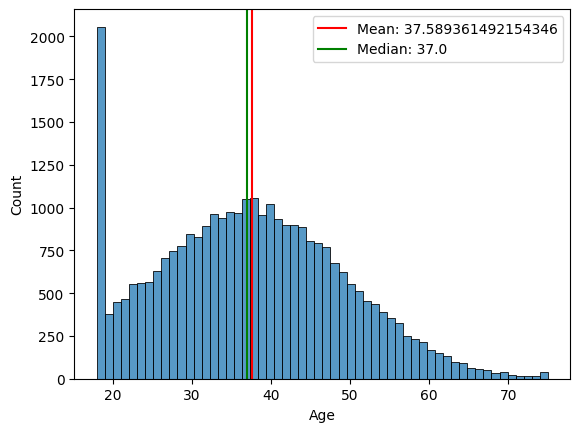

In [29]:
sns.histplot(data=x_train,x="Age")
plt.axvline(x_train["Age"].mean(),color="red",label=f"Mean: {x_train["Age"].mean()}")
plt.axvline(x_train["Age"].median(),color="green",label=f"Median: {x_train["Age"].median()}")
plt.legend()
plt.show()

In [30]:
dfx = x_train.copy()
dfxm = x_train.copy()

In [31]:
dfx["Age"] = dfx["Age"].fillna(round(dfx["Age"].mean())).astype("Int16")

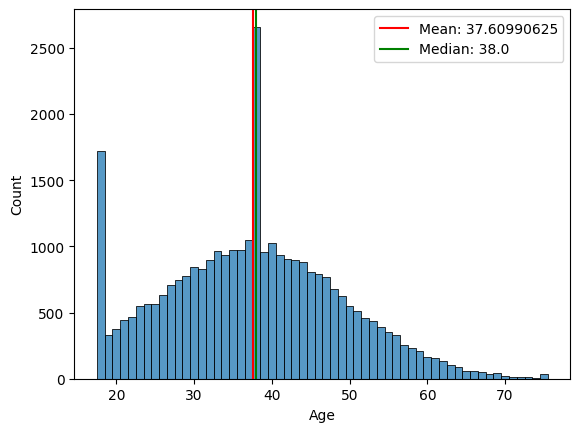

In [32]:
sns.histplot(data=dfx,x="Age",discrete=True)
plt.axvline(dfx["Age"].mean(),color="red",label=f"Mean: {dfx["Age"].mean()}")
plt.axvline(dfx["Age"].median(),color="green",label=f"Median: {dfx["Age"].median()}")
plt.legend()
plt.show()

In [33]:
dfxm["Age"] = dfxm["Age"].fillna(round(dfxm["Age"].median())).astype("Int16")

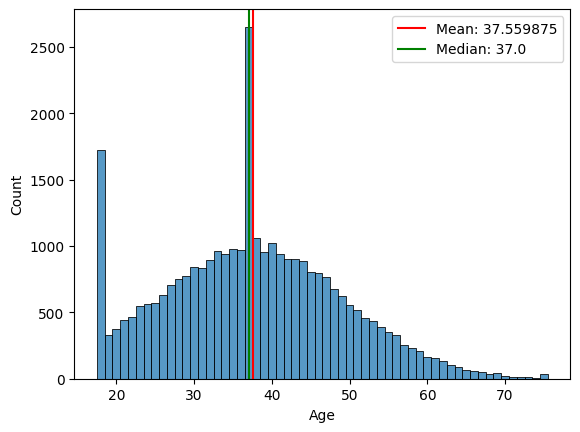

In [34]:
sns.histplot(data=dfxm,x="Age",discrete=True)
plt.axvline(dfxm["Age"].mean(),color="red",label=f"Mean: {dfxm["Age"].mean()}")
plt.axvline(dfxm["Age"].median(),color="green",label=f"Median: {dfxm["Age"].median()}")
plt.legend()
plt.show()

### Next Im gonna use relationship-based imputation

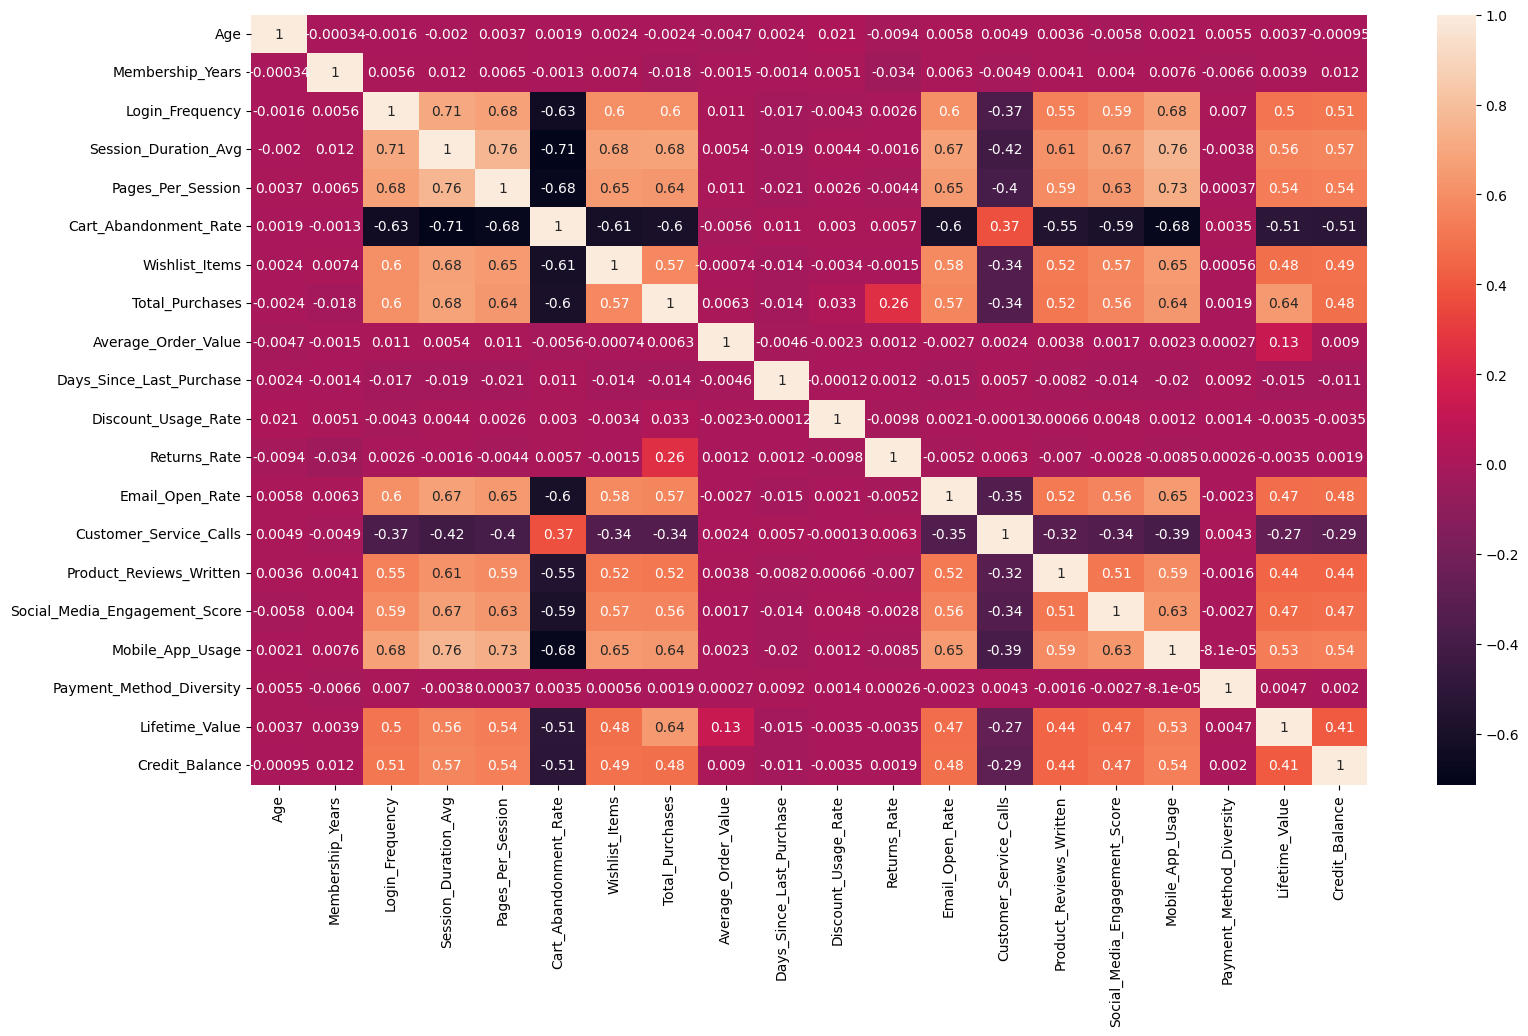

In [35]:
plt.figure(figsize=(18,10))
sns.heatmap(x_train.corr(numeric_only=True), annot=True)
plt.show()

In [36]:
import missingno as msno

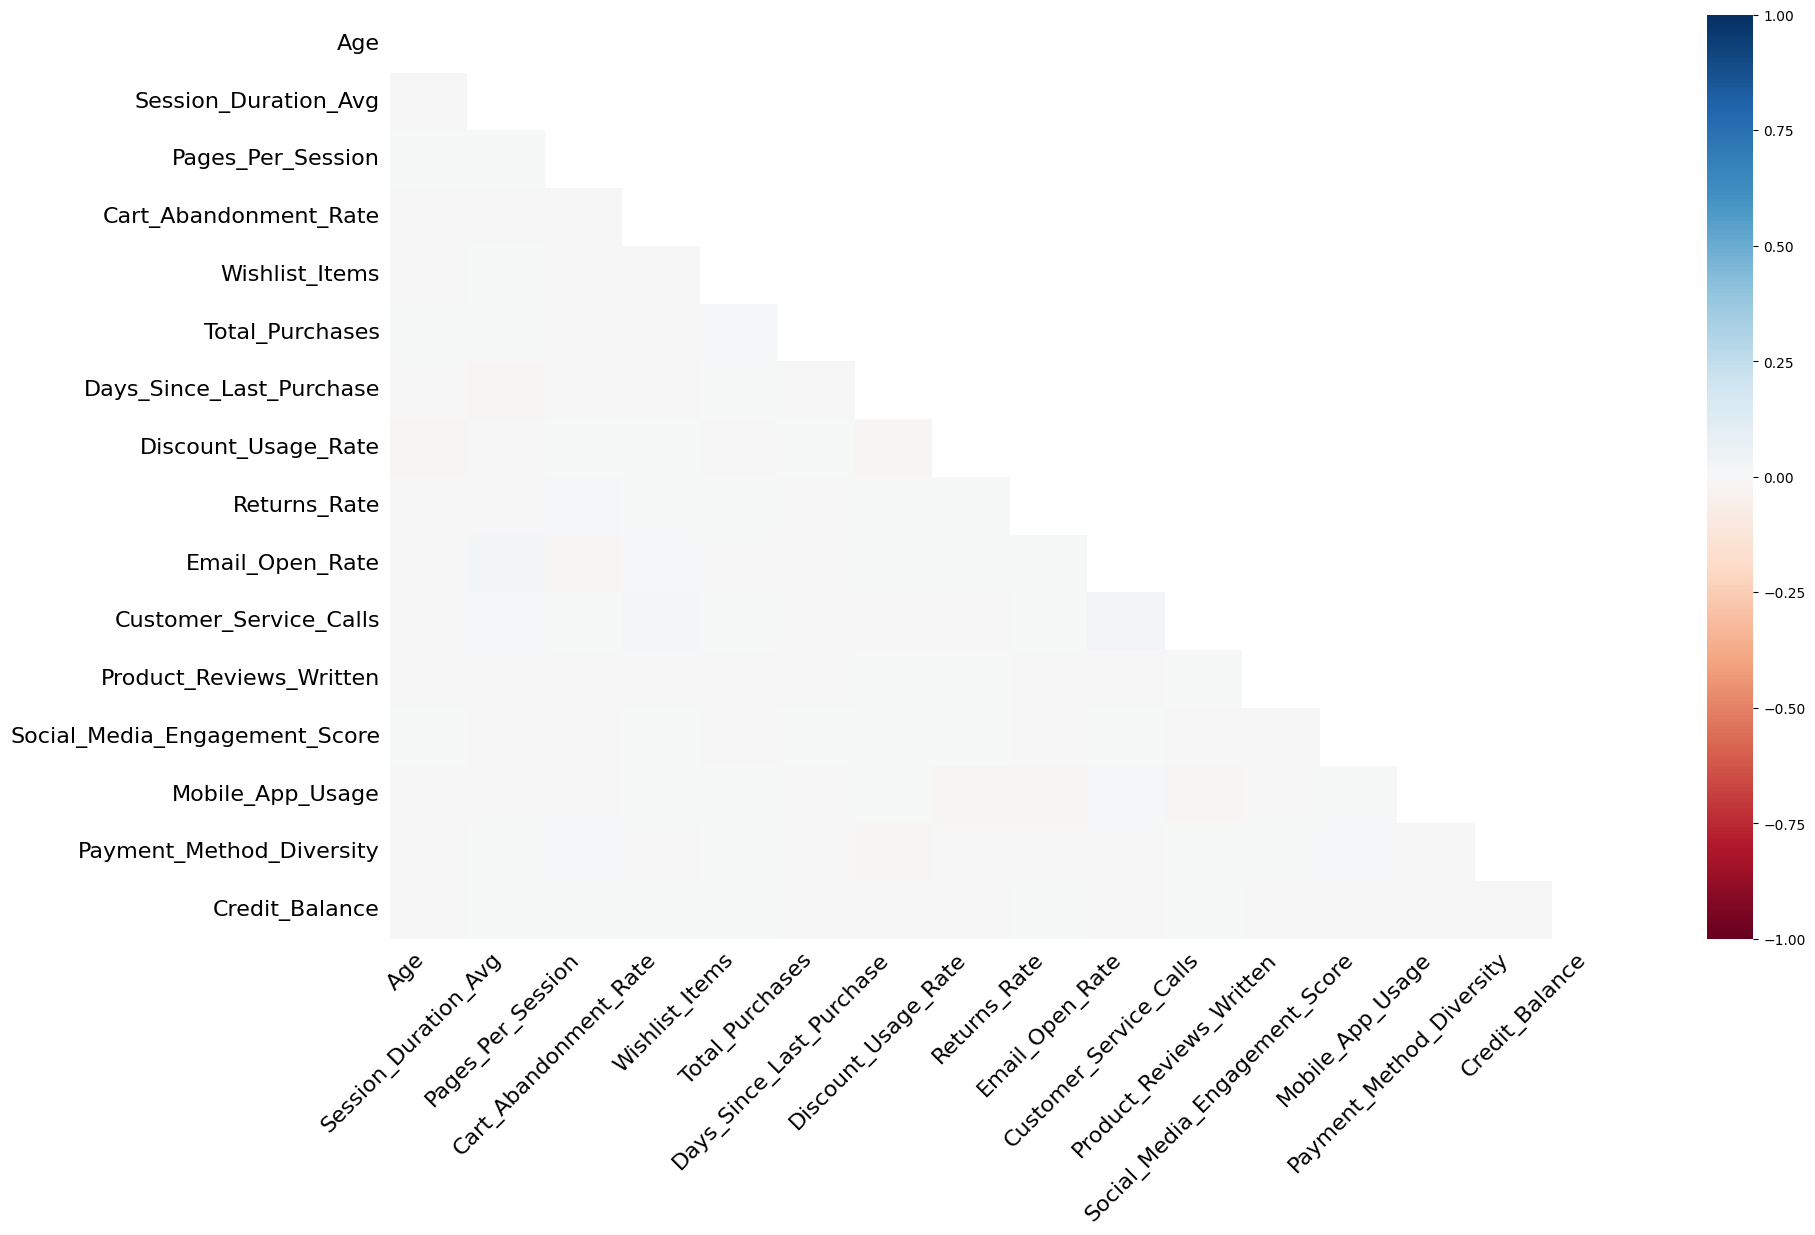

In [37]:
msno.heatmap(x_train)
plt.show()

In [38]:
x_train.isna().corr()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Signup_Quarter
Age,1.000000,NaN,NaN,NaN,NaN,NaN,-0.001287,0.000958,-0.005291,-0.000386,...,-0.003084,-0.005204,-0.005746,-0.005843,0.001667,-0.000643,-0.003271,NaN,-0.000438,NaN
Gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership_Years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Login_Frequency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Session_Duration_Avg,-0.001287,NaN,NaN,NaN,NaN,NaN,1.000000,0.000608,-0.001178,0.000493,...,-0.004694,0.026939,0.009182,-0.002538,-0.003995,-0.005340,0.001865,NaN,0.005502,NaN
Pages_Per_Session,0.000958,NaN,NaN,NaN,NaN,NaN,0.000608,1.000000,-0.005836,-0.003752,...,0.008155,-0.009455,0.001410,-0.007253,-0.001358,-0.004453,0.008095,NaN,0.004418,NaN
Cart_Abandonment_Rate,-0.005291,NaN,NaN,NaN,NaN,NaN,-0.001178,-0.005836,1.000000,-0.001783,...,0.007035,0.012953,0.022273,-0.006304,0.004001,0.001292,-0.005322,NaN,0.004733,NaN
Wishlist_Items,-0.000386,NaN,NaN,NaN,NaN,NaN,0.000493,-0.003752,-0.001783,1.000000,...,0.003535,-0.001267,0.007112,-0.002536,-0.002668,0.002186,0.005175,NaN,0.000228,NaN


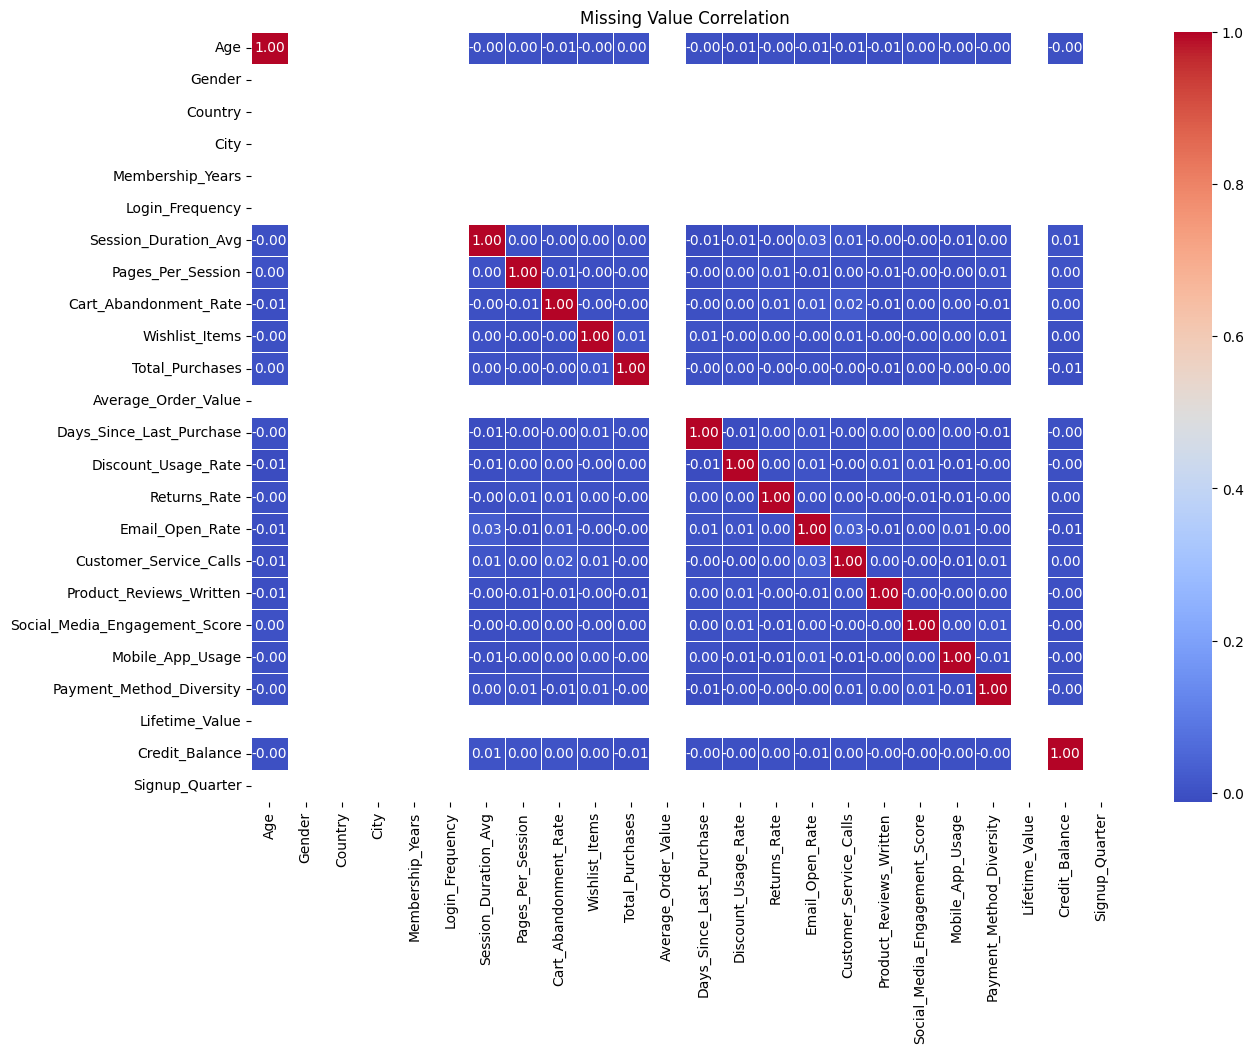

In [39]:
corr = x_train.isna().corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Missing Value Correlation")
plt.show()

<Axes: >

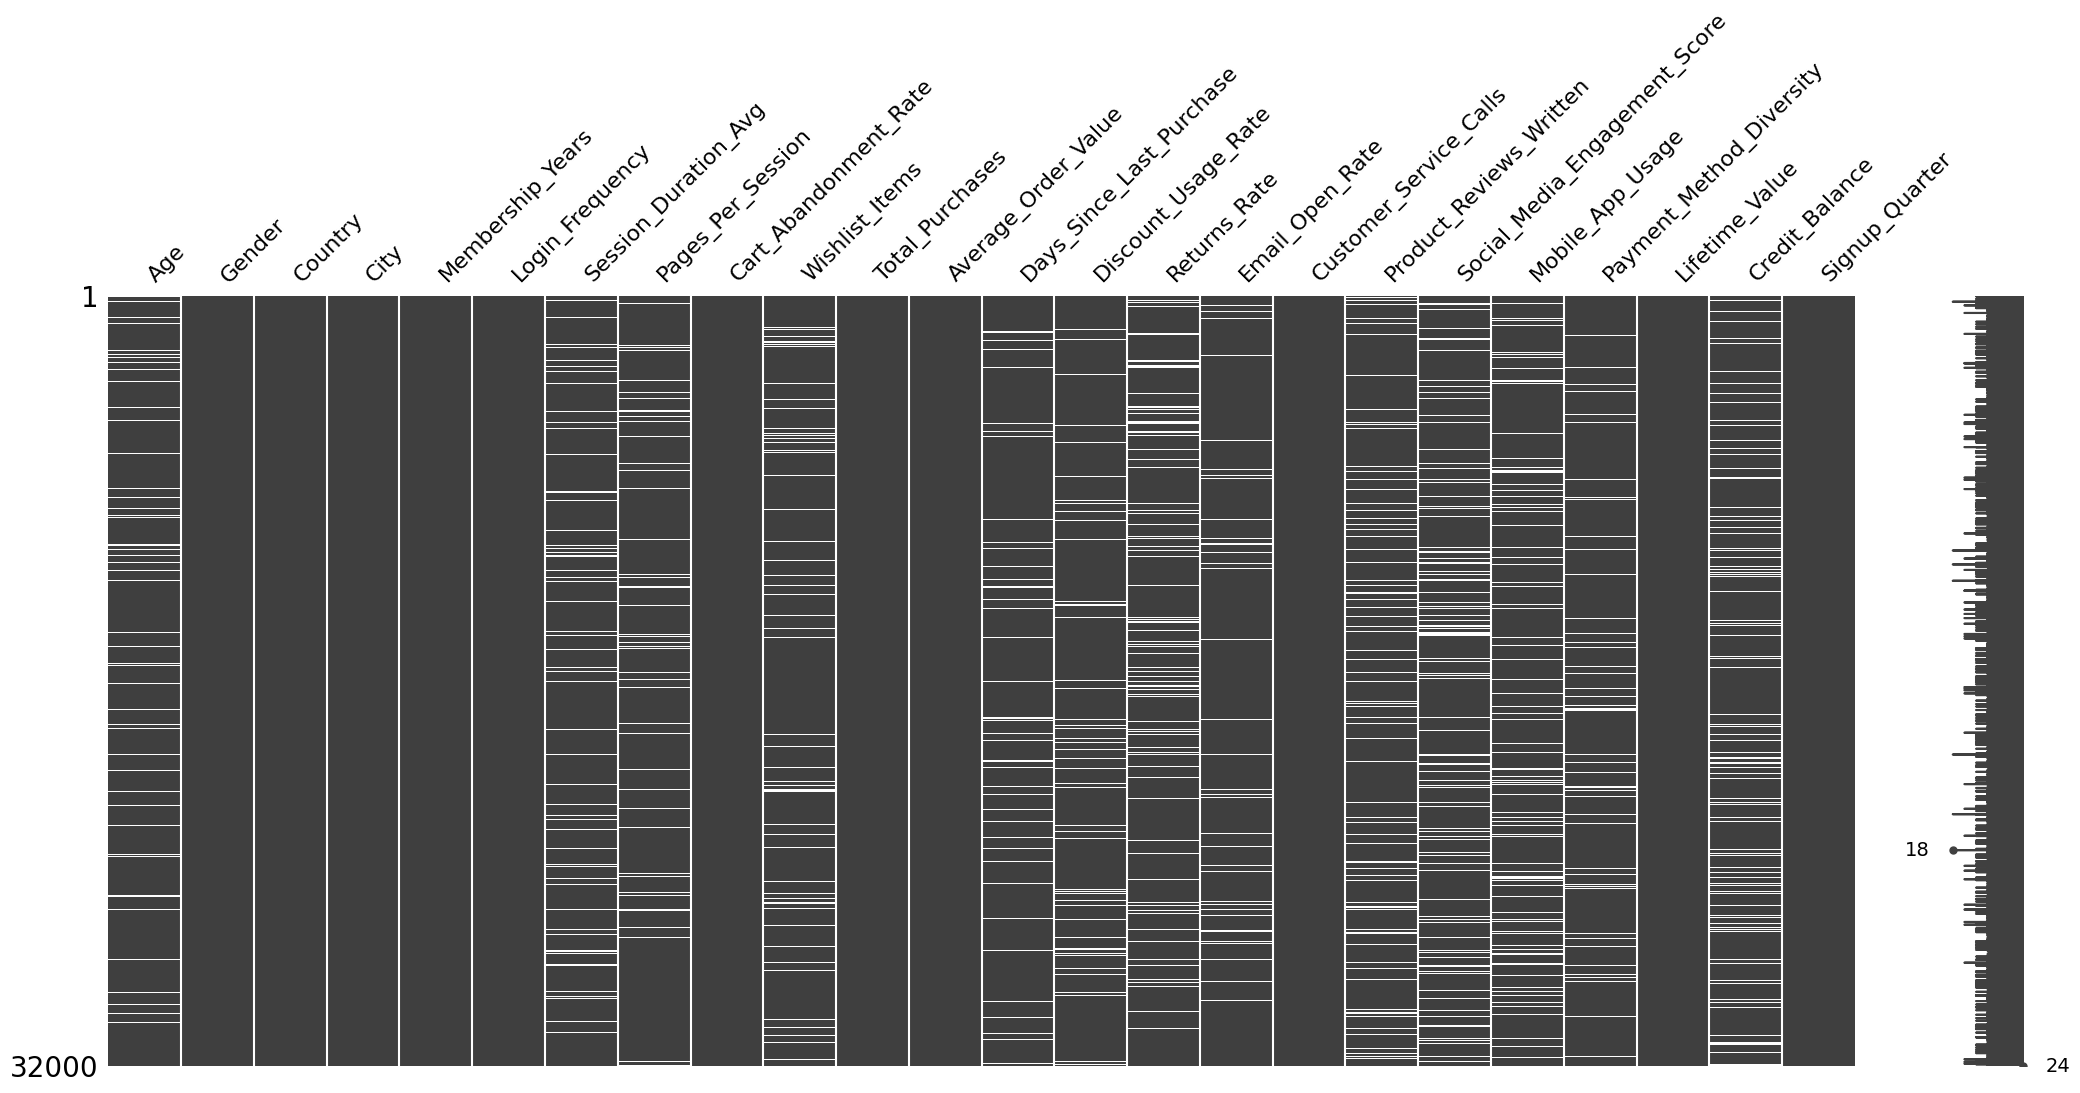

In [40]:
msno.matrix(x_train)

### Since missing correlations are weak: , now we gonna check, actual feature relationships

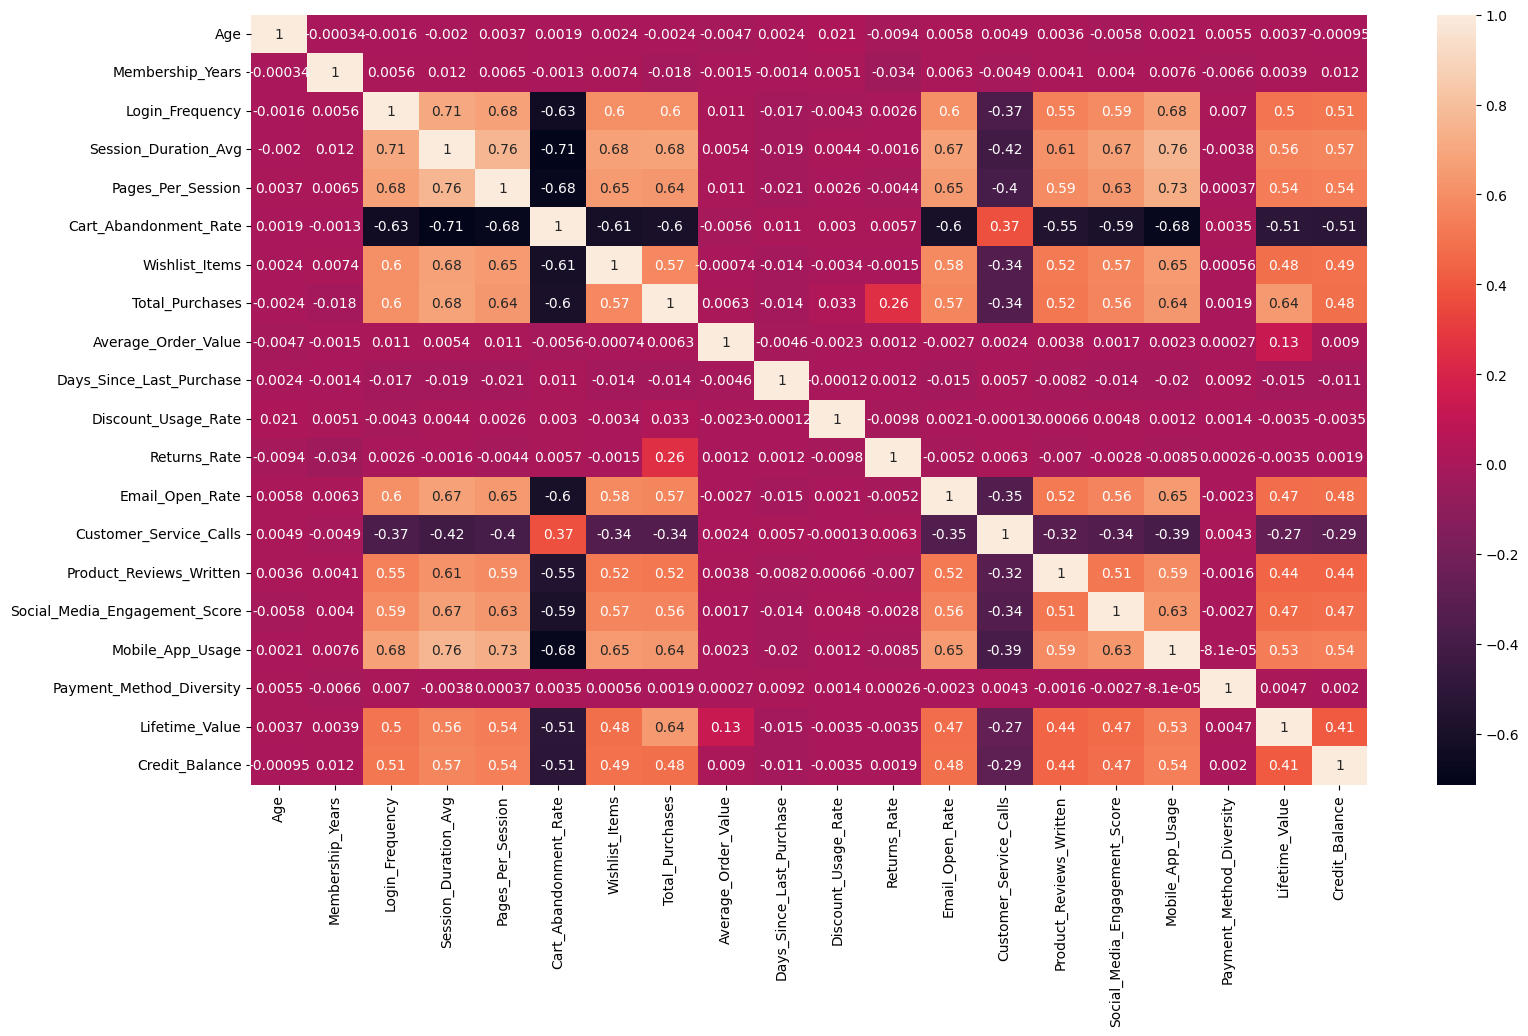

In [41]:
plt.figure(figsize=(18,10))
sns.heatmap(x_train.corr(numeric_only=True), annot=True)
plt.show()

In [42]:
x_train.groupby("Gender")["Age"].mean()

C:\Users\91891\AppData\Local\Temp\ipykernel_14652\2846739777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_train.groupby("Gender")["Age"].mean()


Gender
Female    37.602255
Male      37.582848
Other     37.402574
Name: Age, dtype: Float64

In [43]:
x_train.groupby("City")["Age"].median()

C:\Users\91891\AppData\Local\Temp\ipykernel_14652\2818731083.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_train.groupby("City")["Age"].median()


City
Adelaide       38.0
Bangalore      38.0
Berlin         37.0
Birmingham     36.0
Brisbane       37.0
Calgary        37.0
Chennai        38.0
Chicago        38.0
Cologne        38.0
Delhi          37.0
Frankfurt      38.0
Glasgow        37.0
Hamburg        37.0
Houston        37.0
Hyderabad      39.0
Kyoto          37.0
Leeds          37.0
London         37.0
Los Angeles    37.0
Lyon           37.0
Manchester     38.0
Marseille      37.0
Melbourne      37.0
Montreal       37.0
Mumbai         38.0
Munich         37.0
Nagoya         37.0
New York       37.0
Nice           38.0
Osaka          38.0
Ottawa         38.0
Paris          37.0
Perth          37.0
Phoenix        38.0
Sydney         37.0
Tokyo          36.0
Toronto        37.0
Toulouse       38.0
Vancouver      38.0
Yokohama       37.0
Name: Age, dtype: Float64

#### Age showed very weak correlation with other numerical features in the correlation heatmap. Further analysis using categorical features such as Gender and Country also showed almost identical median age distributions across groups. Therefore, feature-based imputation would not provide meaningful improvement, so median imputation was selected as a simple and robust approach for handling missing values in the Age column.”

In [44]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

so for cont oops
I need to take the col and then plot both mean and median plot, and then a plot after mean imputation and then after median imputation, and then to check the features relationship as already we saw that in missingness heatmap there is no correlation, so directly use feature relationship and should i also check skewness and outliers?? like should i also print them to make a analysis

In [45]:
con_cols = ['Age','Membership_Years', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance']
dis_cols = ["Login_Frequency","Wishlist_Items","Customer_Service_Calls","Product_Reviews_Written","Payment_Method_Diversity"]
cat_cols = ['Gender', 'Country', 'City','Signup_Quarter']

In [46]:
class ContinuousMissingHandler:
    def __init__(self,df,col):
        self.df = df
        self.col = col
        self.con_cols = ['Age','Membership_Years', 'Session_Duration_Avg', 'Pages_Per_Session',
                         'Cart_Abandonment_Rate', 'Total_Purchases','Average_Order_Value', 'Days_Since_Last_Purchase',
                         'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
                         'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance']
        self.dis_cols = ["Login_Frequency","Wishlist_Items","Customer_Service_Calls","Product_Reviews_Written","Payment_Method_Diversity"]
        self.cat_cols = ['Gender', 'Country', 'City','Signup_Quarter']

    def missing_values(self):
        missing = self.df[self.col].isna().sum()
        size = len(self.df)
        missing_percentage = (missing/size) * 100
        return missing_percentage

    def outliers(self):
        q1 = self.df[self.col].quantile(0.25)
        q3 = self.df[self.col].quantile(0.75)
        iqr = q3 - q1
        low_whisker = q1 - 1.5 * iqr
        high_whisker = q3 + 1.5 * iqr
        print("low whisker",low_whisker)
        print("high_whisker",high_whisker)
        data = self.df[self.col].dropna()
        outliers = ((self.df[self.col] < low_whisker) | (self.df[self.col] > high_whisker)).sum()
        outliers_percentage = (outliers/len(data)) * 100
        return outliers_percentage

    def distribution_stats(self):
        print("Mean:", self.df[self.col].mean())
        print("Median:", self.df[self.col].median())
        print("Skewness:", self.df[self.col].skew())

        
    def histplot(self):
        sns.histplot(data=self.df,x=self.col,kde=True,bins=50)
        plt.axvline(self.df[self.col].mean(),color="red",label=f"Original Mean: {self.df[self.col].mean()}")
        plt.axvline(self.df[self.col].median(),color="green",label=f"Original Median: {self.df[self.col].median()}")
        plt.title(f"Original Distribution of {self.col}")
        plt.legend()
        plt.show()

    def histplot_mean(self):
        df_cp = self.df.copy()

        # dfxm["Age"] = dfxm["Age"].fillna(round(dfxm["Age"].median())).astype("Int16")
        mean_fill = df_cp[self.col].fillna(round(df_cp[self.col].mean()))
        sns.histplot(mean_fill,kde=True,bins=50)
        plt.axvline(mean_fill.mean(),color="red",label=f"Mean filled Mean: {mean_fill.mean()}")
        plt.axvline(mean_fill.median(),color="green",label=f"Mean filled Median: {mean_fill.median()}")
        plt.title(f"After Mean Imputation - {self.col}")
        plt.legend()
        plt.show()


    def histplot_median(self):
        df_cp2 = self.df.copy()
        median_fill = df_cp2[self.col].fillna(df_cp2[self.col].median())
        sns.histplot(median_fill,kde=True,bins=50)
        plt.axvline(median_fill.mean(),color="red",label=f"Median filled Mean: {median_fill.mean()}")
        plt.axvline(median_fill.median(),color="green",label=f"Median filled Median: {median_fill.median()}")
        plt.title(f"After Median Imputation - {self.col}")
        plt.legend()
        plt.show()

    # def change_in_mean_median(self):
        

        
    def other_cols_relation(self):
        print("\nNumerical + discrete feature relationship:")
        
        num_cols = self.con_cols + self.dis_cols
        
        corr = (self.df[num_cols].corr(numeric_only=True)[self.col].sort_values(ascending=False))
        
        print(corr)
        
        print("\nCategorical group median comparison:")
        
        for cat in self.cat_cols:
            print(f"\n{cat}:")
            print(self.df.groupby(cat,observed=False)[self.col].median())

    def flow(self):
        if self.df[self.col].isna().sum() != 0:
            print(f"Missing percentage: {self.missing_values()}")
            self.distribution_stats()
            print(f"Outliers percentage: {self.outliers()}")
            self.histplot()
            self.histplot_mean()
            self.histplot_median()
            self.other_cols_relation()
        else:
            print("No missing values")

Missing percentage: 5.003125
Mean: 37.589361492154346
Median: 37.0
Skewness: 0.2384135774043969
low whisker 5.0
high_whisker 69.0
Outliers percentage: 0.33553735320240796


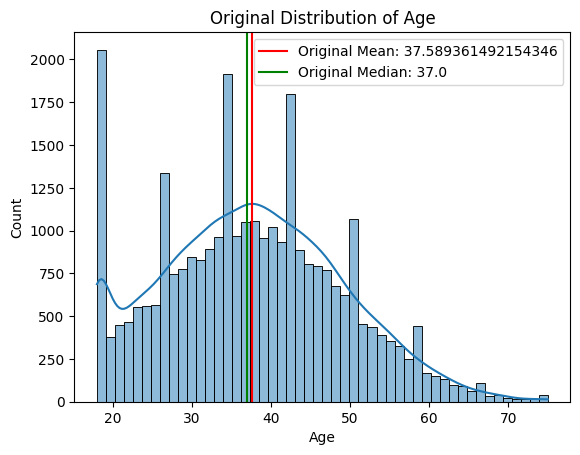

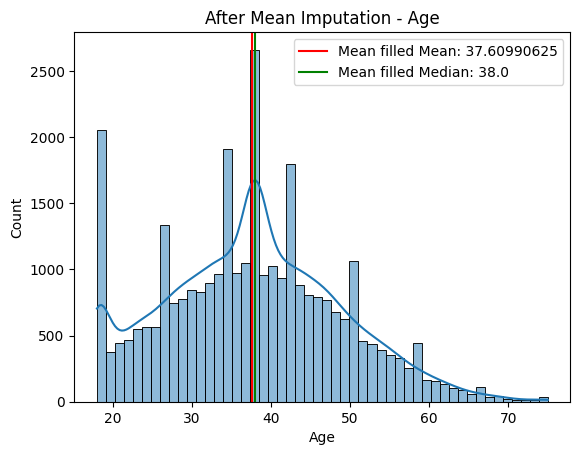

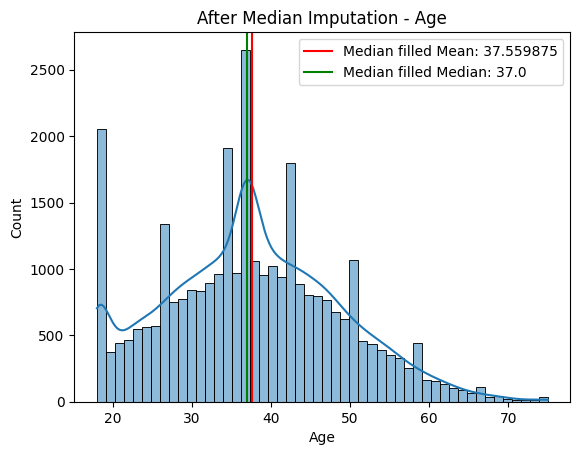


Numerical + discrete feature relationship:
Age                              1.000000
Discount_Usage_Rate              0.020961
Email_Open_Rate                  0.005818
Payment_Method_Diversity         0.005458
Customer_Service_Calls           0.004854
Lifetime_Value                   0.003690
Pages_Per_Session                0.003666
Product_Reviews_Written          0.003619
Days_Since_Last_Purchase         0.002420
Wishlist_Items                   0.002367
Mobile_App_Usage                 0.002060
Cart_Abandonment_Rate            0.001943
Membership_Years                -0.000338
Credit_Balance                  -0.000948
Login_Frequency                 -0.001623
Session_Duration_Avg            -0.002035
Total_Purchases                 -0.002354
Average_Order_Value             -0.004705
Social_Media_Engagement_Score   -0.005782
Returns_Rate                    -0.009395
Name: Age, dtype: float64

Categorical group median comparison:

Gender:
Gender
Female    37.0
Male      37.0
Other 

In [47]:
o = ContinuousMissingHandler(x_train,"Age")
o.flow()

### Age
* So after seeing everything, median imputation is best

In [48]:
age_median = x_train["Age"].median()
x_train["Age"] = x_train["Age"].fillna(age_median)
x_test["Age"] = x_test["Age"].fillna(age_median)

Missing percentage: 12.00625
Mean: 28.810434
Median: 26.8
Skewness: 0.52659863
low whisker -32.9
high_whisker 87.899994
Outliers percentage: 0.5291569003480361


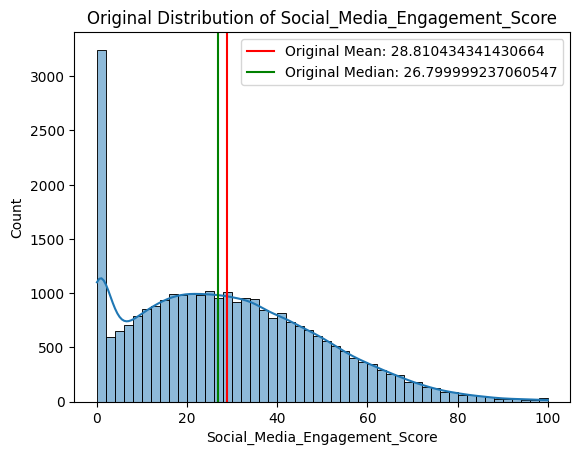

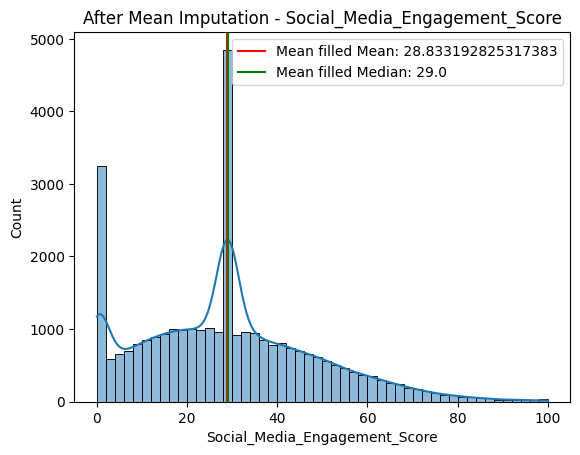

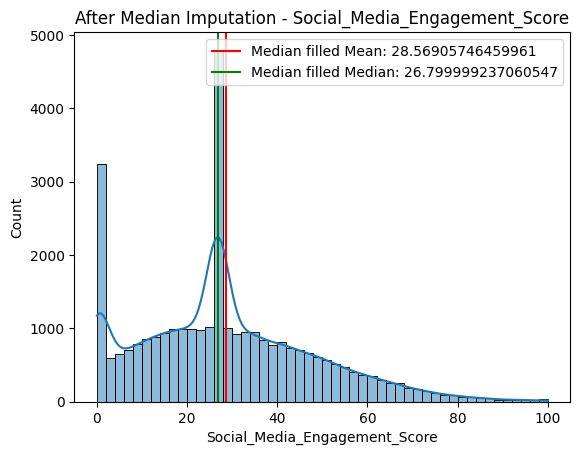


Numerical + discrete feature relationship:
Social_Media_Engagement_Score    1.000000
Session_Duration_Avg             0.666187
Pages_Per_Session                0.632154
Mobile_App_Usage                 0.629015
Login_Frequency                  0.590923
Wishlist_Items                   0.566358
Email_Open_Rate                  0.562700
Total_Purchases                  0.559701
Product_Reviews_Written          0.514620
Credit_Balance                   0.473685
Lifetime_Value                   0.465046
Discount_Usage_Rate              0.004770
Membership_Years                 0.004015
Average_Order_Value              0.001720
Payment_Method_Diversity        -0.002698
Returns_Rate                    -0.002805
Age                             -0.005589
Days_Since_Last_Purchase        -0.014128
Customer_Service_Calls          -0.343950
Cart_Abandonment_Rate           -0.591850
Name: Social_Media_Engagement_Score, dtype: float64

Categorical group median comparison:

Gender:
Gender
Female    

In [49]:
o = ContinuousMissingHandler(x_train,"Social_Media_Engagement_Score")
o.flow()

### So here, if we see this col has some good correlation with other cols, so im gonna use the cols with > abs(0.6) corr in KNN imputation, and I also saw other cols has missing values, so first lets fill them with mean or median based on distribution and outliers and then impute. 

In [51]:
choosen_cols = ["Social_Media_Engagement_Score","Session_Duration_Avg", "Pages_Per_Session","Mobile_App_Usage"]
# from univariate analysis notebook, it is given that Session_Duration_Avg and Pages_Per_Session,Mobile_App_Usage are symmetric, so we gonna use mean
social_knn = x_train[choosen_cols].copy()
social_knn["Session_Duration_Avg"] = social_knn["Session_Duration_Avg"].fillna(social_knn["Session_Duration_Avg"].mean())
social_knn["Pages_Per_Session"] = social_knn["Pages_Per_Session"].fillna(social_knn["Pages_Per_Session"].mean())
social_knn["Mobile_App_Usage"] = social_knn["Mobile_App_Usage"].fillna(social_knn["Mobile_App_Usage"].mean())


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

In [53]:
scaler = StandardScaler()
scaled_train = scaler.fit_transform(social_knn)
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(scaled)
# here imputed becomes Numpy array, in arrays, it loses col names and row indexes, so change it to a dataframe
# now convert back to original values
imputed_original = scaler.inverse_transform(imputed)
imputed_original = pd.DataFrame(imputed_original,columns=choosen_cols,index=social_knn.index)
x_train["Social_Media_Engagement_Score"] = imputed_original["Social_Media_Engagement_Score"]
# x_test["Social_Media_Engagement_Score"] = imputed_original["Social_Media_Engagement_Score"]

np.int64(0)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

choosen_cols = [
    "Social_Media_Engagement_Score",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Mobile_App_Usage"
]

helper_cols = [
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Mobile_App_Usage"
]

# -----------------------------
# 1. Create train and test copies
# -----------------------------
social_knn_train = x_train[choosen_cols].copy()
social_knn_test = x_test[choosen_cols].copy()

# -----------------------------
# 2. Fill helper columns using TRAIN means only
# -----------------------------
helper_means = {}

for col in helper_cols:
    helper_means[col] = social_knn_train[col].mean()
    
    social_knn_train[col] = social_knn_train[col].fillna(helper_means[col])
    social_knn_test[col] = social_knn_test[col].fillna(helper_means[col])

# -----------------------------
# 3. Scale train data
# -----------------------------
scaler = StandardScaler()

scaled_train = scaler.fit_transform(social_knn_train)

# -----------------------------
# 4. Fit KNN imputer on train
# -----------------------------
imputer = KNNImputer(n_neighbors=5)

imputed_train = imputer.fit_transform(scaled_train)

# -----------------------------
# 5. Convert train back to original scale
# -----------------------------
imputed_train_original = scaler.inverse_transform(imputed_train)

imputed_train_original = pd.DataFrame(
    imputed_train_original,
    columns=choosen_cols,
    index=social_knn_train.index
)

# -----------------------------
# 6. Update x_train
# -----------------------------
x_train["Social_Media_Engagement_Score"] = (
    imputed_train_original["Social_Media_Engagement_Score"]
)

# -----------------------------
# 7. Apply SAME scaler + imputer on test
# -----------------------------
scaled_test = scaler.transform(social_knn_test)

imputed_test = imputer.transform(scaled_test)

# -----------------------------
# 8. Convert test back to original scale
# -----------------------------
imputed_test_original = scaler.inverse_transform(imputed_test)

imputed_test_original = pd.DataFrame(
    imputed_test_original,
    columns=choosen_cols,
    index=social_knn_test.index
)

# -----------------------------
# 9. Update x_test
# -----------------------------
x_test["Social_Media_Engagement_Score"] = (
    imputed_test_original["Social_Media_Engagement_Score"]
)